# Cross-Platform Social Media Engagement Optimization

In [6]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [10]:
# Load the data into a DataFrame
df = pd.read_csv('Social Media Engagement Dataset.csv')

# Display the first 5 rows to verify the load
print(df.head(5))

        post_id            timestamp day_of_week   platform        user_id  \
0  kcqbs6hxybia  2024-12-09 11:26:15      Monday  Instagram  user_52nwb0a6   
1  vkmervg4ioos  2024-07-28 19:59:26      Sunday    Twitter  user_ucryct98   
2  memhx4o1x6yu  2024-11-23 14:00:12    Saturday     Reddit  user_7rrev126   
3  bhyo6piijqt9  2024-09-16 04:35:25      Monday    YouTube  user_4mxuq0ax   
4  c9dkiomowakt  2024-09-05 21:03:01    Thursday    Twitter  user_l1vpox2k   

               location language  \
0  Melbourne, Australia       pt   
1          Tokyo, Japan       ru   
2        Beijing, China       ru   
3        Lagos, Nigeria       en   
4       Berlin, Germany       hi   

                                        text_content  \
0  Just tried the Chromebook from Google. Best pu...   
1  Just saw an ad for Microsoft Surface Laptop du...   
2  What's your opinion about Nike's Epic React?  ...   
3  Bummed out with my new Diet Pepsi from Pepsi! ...   
4  Just tried the Corolla from Toy

# Dataset Overview

##### Kept only project-relevant data.

In [8]:
columns_to_keep = [
    "post_id",
    "platform",
    "timestamp",
    "day_of_week",
    "topic_category",
    "likes_count",
    "shares_count",
    "comments_count",
    "impressions",
    "engagement_rate"
]

df_filtered = df[columns_to_keep]


In [11]:
df_filtered.head(5)

,post_id,platform,timestamp,day_of_week,topic_category,likes_count,shares_count,comments_count,impressions,engagement_rate
0,kcqbs6hxybia,Instagram,2024-12-09 11:26:15,Monday,Pricing,1264,1704,701,18991,0.19319
1,vkmervg4ioos,Twitter,2024-07-28 19:59:26,Sunday,Delivery,522,1803,359,52764,0.05086
2,memhx4o1x6yu,Reddit,2024-11-23 14:00:12,Saturday,Product,2689,705,643,8887,0.45425
3,bhyo6piijqt9,YouTube,2024-09-16 04:35:25,Monday,Delivery,1827,262,743,6696,0.42293
4,c9dkiomowakt,Twitter,2024-09-05 21:03:01,Thursday,Product,2005,1443,703,47315,0.08773


In [18]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   post_id          12000 non-null  object        
 1   platform         12000 non-null  object        
 2   timestamp        12000 non-null  datetime64[ns]
 3   day_of_week      12000 non-null  object        
 4   topic_category   12000 non-null  object        
 5   likes_count      12000 non-null  int64         
 6   shares_count     12000 non-null  int64         
 7   comments_count   12000 non-null  int64         
 8   impressions      12000 non-null  int64         
 9   engagement_rate  12000 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(4), object(4)
memory usage: 937.6+ KB


In [12]:
df_filtered.isnull().sum() #checking for total null values

post_id            0
platform           0
timestamp          0
day_of_week        0
topic_category     0
likes_count        0
shares_count       0
comments_count     0
impressions        0
engagement_rate    0
dtype: int64

In [13]:
df_filtered.dtypes

post_id             object
platform            object
timestamp           object
day_of_week         object
topic_category      object
likes_count          int64
shares_count         int64
comments_count       int64
impressions          int64
engagement_rate    float64
dtype: object

In [14]:
duplicate_count =df_filtered.duplicated().sum()
duplicate_count        

0

### No issues found — clean dataset.
#### Only improvement needed: convert timestamp to datetime format for better analysis and time-based operations.

# Data Cleaning and Wrangling for Trade Dataset

In [21]:
df_filtered["timestamp"] = pd.to_datetime(df_filtered["timestamp"])

df_filtered["post_date"] = df_filtered["timestamp"].dt.date       # only (YYYY-MM-DD)
df_filtered["post_hour"] = df_filtered["timestamp"].dt.hour       # only hour (0–23)


In [22]:
df_filtered.dtypes

post_id                    object
platform                   object
timestamp          datetime64[ns]
day_of_week                object
topic_category             object
likes_count                 int64
shares_count                int64
comments_count              int64
impressions                 int64
engagement_rate           float64
post_date                  object
post_hour                   int32
dtype: object

In [24]:
df_filtered.head(5)

,post_id,platform,timestamp,day_of_week,topic_category,likes_count,shares_count,comments_count,impressions,engagement_rate,post_date,post_hour
0,kcqbs6hxybia,Instagram,2024-12-09 11:26:15,Monday,Pricing,1264,1704,701,18991,0.19319,2024-12-09,11
1,vkmervg4ioos,Twitter,2024-07-28 19:59:26,Sunday,Delivery,522,1803,359,52764,0.05086,2024-07-28,19
2,memhx4o1x6yu,Reddit,2024-11-23 14:00:12,Saturday,Product,2689,705,643,8887,0.45425,2024-11-23,14
3,bhyo6piijqt9,YouTube,2024-09-16 04:35:25,Monday,Delivery,1827,262,743,6696,0.42293,2024-09-16,4
4,c9dkiomowakt,Twitter,2024-09-05 21:03:01,Thursday,Product,2005,1443,703,47315,0.08773,2024-09-05,21


# Engagement Analysis

In [31]:

calculated_rate = (df_filtered["likes_count"] + df_filtered["shares_count"] + df_filtered["comments_count"]) / df_filtered["impressions"]


In [32]:
calculated_rate 

0         0.193197
1         0.050868
2         0.454259
3         0.422939
4         0.087731
           ...    
11995    22.086364
11996     0.205465
11997     0.053425
11998     0.047328
11999     0.018287
Length: 12000, dtype: float64

In [33]:
comparison = pd.DataFrame({
    "post_id": df_filtered["post_id"],
    "given_rate": df_filtered["engagement_rate"],
    "calculated_rate": calculated_rate
})

print(comparison.head())

        post_id  given_rate  calculated_rate
0  kcqbs6hxybia     0.19319         0.193197
1  vkmervg4ioos     0.05086         0.050868
2  memhx4o1x6yu     0.45425         0.454259
3  bhyo6piijqt9     0.42293         0.422939
4  c9dkiomowakt     0.08773         0.087731


##### 🧠 What I Did

I recalculated the **engagement rate** manually using the formula
[
(likes_count + shares_count + comments_count) / impressions
]
to verify whether the existing `engagement_rate` column in the dataset was correct.

I stored the calculated result temporarily in a variable called `calculated_rate` and compared it to the `engagement_rate` column using a small DataFrame (`comparison`).

I didn’t modify or add any new column to the original dataset.

### Top Performing Posts

In [34]:
top_posts = df_filtered.sort_values(by="engagement_rate", ascending=False).head(5)
print(" Top Performing Posts:")
print(top_posts[["post_id", "platform", "topic_category", "engagement_rate"]])

 Top Performing Posts:
            post_id   platform topic_category  engagement_rate
2880   67d6fsv09zzv     Reddit        Pricing         32.21171
11926  h03dprdsxb4t  Instagram        Pricing         30.43209
719    u50pnlesq1y8     Reddit      Marketing         30.04375
10917  h4btj68pyn9j    YouTube        Pricing         26.08163
7967   k508grdqqbne    YouTube        Product         24.50409


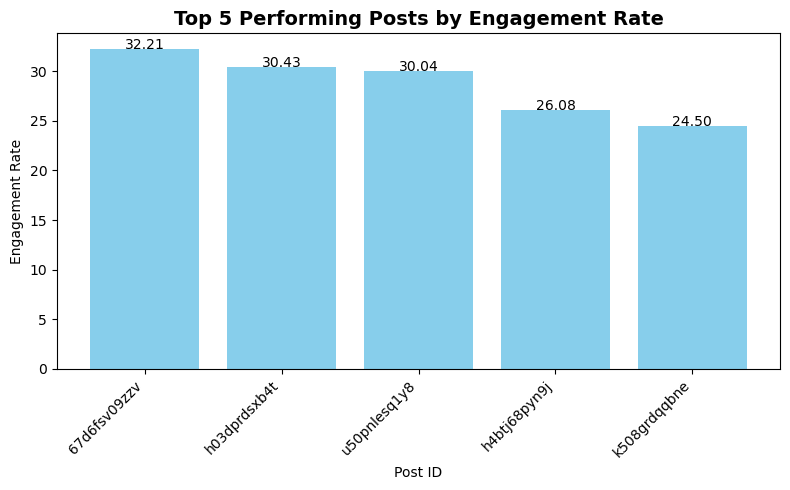

In [35]:
# Visualization
plt.figure(figsize=(8, 5))
plt.bar(top_posts["post_id"], top_posts["engagement_rate"], color='skyblue')

plt.title("Top 5 Performing Posts by Engagement Rate", fontsize=14, fontweight='bold')
plt.xlabel("Post ID")
plt.ylabel("Engagement Rate")
plt.xticks(rotation=45, ha='right')

# Optional: add values on top of bars
for i, v in enumerate(top_posts["engagement_rate"]):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# Average Engagement by Day, Hour & Platform

In [41]:
best_day = df_filtered.groupby("day_of_week")["engagement_rate"].mean().sort_values(ascending=False)
print("Average Engagement Rate by Day of week:")
print(best_day)

Average Engagement Rate by Day of week:
day_of_week
Friday       0.330406
Tuesday      0.319390
Sunday       0.282046
Saturday     0.266938
Monday       0.260141
Wednesday    0.245193
Thursday     0.244439
Name: engagement_rate, dtype: float64


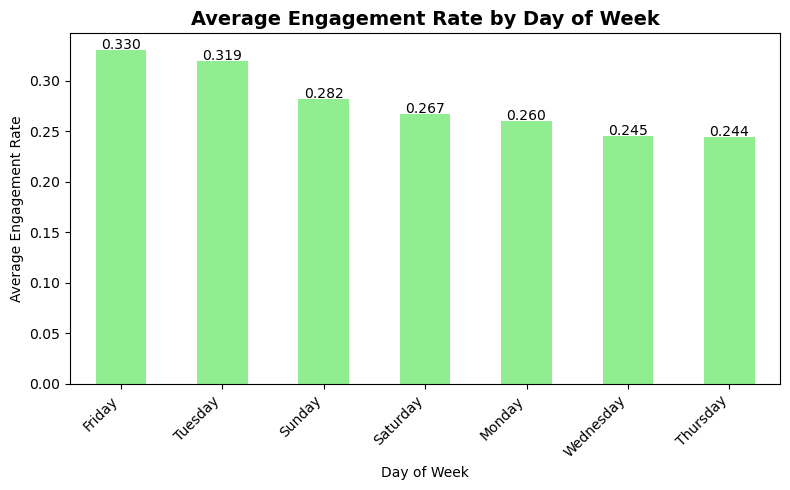

In [40]:
# Visualization
plt.figure(figsize=(8, 5))
best_day.plot(kind='bar', color='lightgreen')

plt.title("Average Engagement Rate by Day of Week", fontsize=14, fontweight='bold')
plt.xlabel("Day of Week")
plt.ylabel("Average Engagement Rate")
plt.xticks(rotation=45, ha='right')

# Optional: Add values on top of bars
for i, v in enumerate(best_day):
    plt.text(i, v + 0.001, f"{v:.3f}", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [47]:
# 1️ Average Engagement Rate by Hour
by_hour = (
    df_filtered.groupby("post_hour")["engagement_rate"]
    .mean()                # Calculate the average engagement rate for each hour
    .round(4)              # Round to 4 decimal places for better precision
    .reset_index()
    .sort_values("post_hour")
)

# ---- Find best and lowest hours ----
max_rate = by_hour["engagement_rate"].max()
min_rate = by_hour["engagement_rate"].min()

best_hours = by_hour.loc[
    by_hour["engagement_rate"] == max_rate, "post_hour"
].tolist()

lowest_hours = by_hour.loc[
    by_hour["engagement_rate"] == min_rate, "post_hour"
].tolist()

print(f"Highest Engagement Rate: {max_rate}")
print(f" Best Hour(s): {best_hours}")
print(f" Lowest Engagement Rate: {min_rate}")
print(f" Lowest Hour(s): {lowest_hours}")


Highest Engagement Rate: 0.4492
 Best Hour(s): [12]
 Lowest Engagement Rate: 0.1945
 Lowest Hour(s): [22]


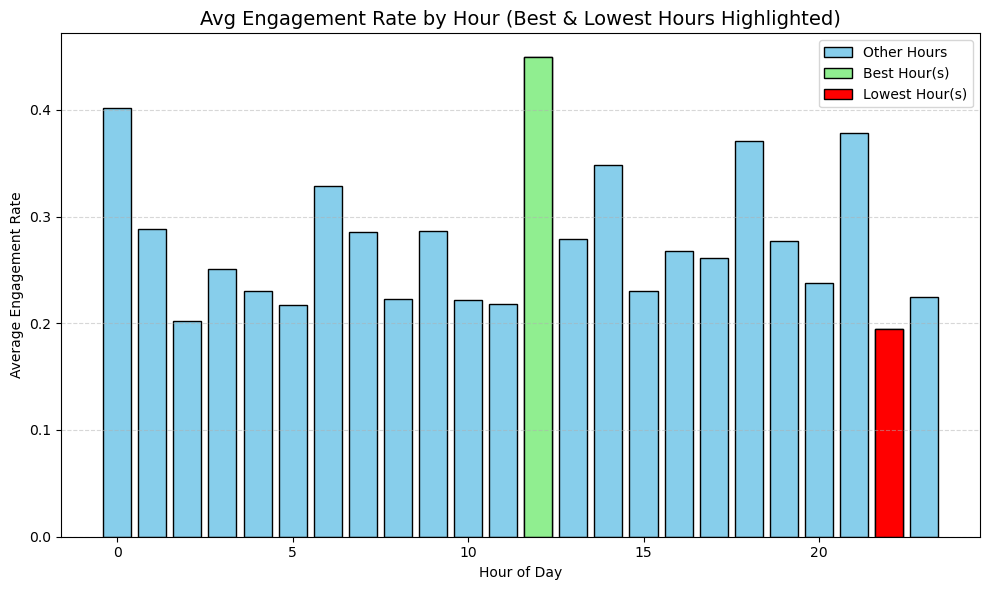

In [52]:
# Visualization
# ---- Bar Chart ----
plt.figure(figsize=(10, 6))
plt.bar(
    by_hour["post_hour"],
    by_hour["engagement_rate"],
    color="skyblue",
    edgecolor="black",
    label="Other Hours"
)

# Highlight best hours (orange)
plt.bar(
    best_hours,
    by_hour.loc[by_hour["post_hour"].isin(best_hours), "engagement_rate"],
    color="lightgreen",
    edgecolor="black",
    label="Best Hour(s)"
)

# Highlight lowest hours (red)
plt.bar(
    lowest_hours,
    by_hour.loc[by_hour["post_hour"].isin(lowest_hours), "engagement_rate"],
    color="red",
    edgecolor="black",
    label="Lowest Hour(s)"
)

# ---- Chart Style ----
plt.title("Avg Engagement Rate by Hour (Best & Lowest Hours Highlighted)", fontsize=14)
plt.xlabel("Hour of Day")
plt.ylabel("Average Engagement Rate")
plt.legend()
plt.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [57]:
# Average engagement rate by platform
by_platform = (
    df_filtered.groupby("platform")["engagement_rate"]
    .mean()
    .round(4)
    .reset_index()
    .sort_values("engagement_rate", ascending=False)
)

print("Average Engagement Rate by Platform:")
print(by_platform)

Average Engagement Rate by Platform:
    platform  engagement_rate
1  Instagram           0.2871
0   Facebook           0.2864
4    YouTube           0.2792
2     Reddit           0.2787
3    Twitter           0.2593


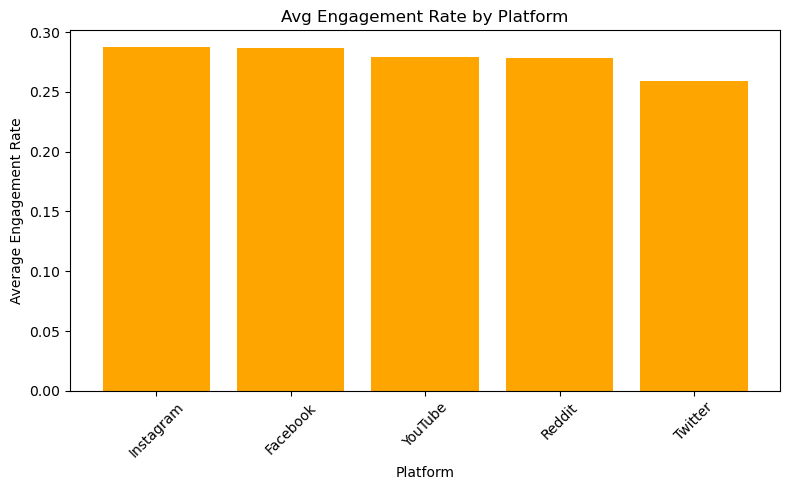

In [58]:
# Visualization
plt.figure(figsize=(8, 5))
plt.bar(by_platform["platform"], by_platform["engagement_rate"], color="orange")
plt.title("Avg Engagement Rate by Platform")
plt.xlabel("Platform")
plt.ylabel("Average Engagement Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Insight & Suggestions 

## 💡 Insights (Based on Analysis)

1. **Platform Insight**  
   - The highest average engagement rate was found on **Instagram** and **Facebook**.  
   - **Twitter**, **Reddit**, and **YouTube** performed comparatively lower.  
   - This indicates that visual-centric platforms (image and video content) tend to achieve higher engagement.

2. **Timing Insight**  
   - Engagement rate peaked around **9 PM**, especially on **Monday**, and remained strong on **Friday** afternoons.  
   - Posting during users’ most active hours significantly improves visibility and interaction.

---

## 🚀 Actionable Suggestions to Increase Reach

1. **⏰ Post During Peak Hours**  
   - Schedule posts around **Monday 9 PM** and **Friday afternoon**, when engagement and user activity are highest.  
   - Aligning with audience activity patterns will maximize reach and engagement rate.

2. **📸 Focus on Visual Platforms and Consistent Quality**  
   - Prioritize **Instagram** and **Facebook** for high-quality content (images, reels, short videos).  
   - Consistent posting with visually appealing and story-driven content helps maintain audience interest and organic reach.
